In [1]:
from pathlib import Path

import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt

data_dir = Path("../data")

In [2]:
df = pd.read_csv(data_dir / "raw/metadata/AllClinical00.csv")
df2 = pd.read_csv(data_dir / "processed/variable_types.csv")

In [3]:
df2.drop(["ElementName_candidate","Size", "Required", "Aliases"], axis=1)

,AllClinical00,Dataset,DataType,Type,ElementDescription,ValueRange,Notes
0,ID,Participant Identifier,NaN,Identifier,Release ID,NaN,NaN
1,VERSION,Medical Outcomes,String,Unknown,Version/code of assessment,NaN,"e.g., Self-Report, Parent Form, Short Form, Re..."
2,V00BLDCOLL,Biomarkers,Integer,Nominal,Phlebotomy: which draw(s) blood obtained at,0::3,0= No sample collected at visit; 1= Sample at ...
3,V00BLDHRS1,Biomarkers,String,Time,Phlebotomy: time venipuncture completed (first...,NaN,NaN
4,V00BLDHRS2,Biomarkers,String,Time,Phlebotomy: time venipuncture completed (repea...,NaN,NaN
...,...,...,...,...,...,...,...
1182,V00PASE6HR,Physical Activity,Integer,Ordinal,"Leisure activities: muscle strength/endurance,...",1::4,"1=Less than 1 hour; 2=1 hour, but less than 2 ..."
1183,V00WEEKWK,Medical History,Integer,Count,"About how many weeks worked, past 12 months (i...",NaN,NaN
1184,V00WKHR7CV,Medical History,Integer,Count,Occupational activities: number of hours worke...,NaN,NaN
1185,V00WORK7,Medical History,Integer,Binary,"Occupational activities: work (pay/volunteer),...",0;1,0=No; 1=Yes


In [4]:
# Which columns have actual missing values
df.isna().sum().loc[lambda x: x > 0]

V00BLDHRS1      18
V00BLDHRS2    4767
V00BLSURD1    4791
V00BLSURD2    4796
V00hoursp1      38
              ... 
V00HOURWK     1826
V00MISSWK     1802
V00PASE         29
V00WEEKWK     1820
V00WKHR7CV       7
Length: 261, dtype: int64

In [5]:
blank   = df.isna()
coded   = df.astype(str).apply(lambda s: s.str.startswith(".:"))

# Cells with either type of missing
missing = blank | coded

summary = pd.DataFrame({
    "blank" : blank.sum(),
    "coded" : coded.sum(),
})

# 
summary = summary[summary.sum(axis=1) > 0]

summary["dataset"] = summary.index.map(df2.set_index("AllClinical00")["Dataset"])

print(summary.head())

            blank  coded     dataset
V00BLDHRS1     18      0  Biomarkers
V00BLDHRS2   4767      0  Biomarkers
V00BLDRAW2      0   4752  Biomarkers
V00BLSURD1   4791      0  Biomarkers
V00BLSURD2   4796      0  Biomarkers


Text(0, 0.5, 'Number of Columns')

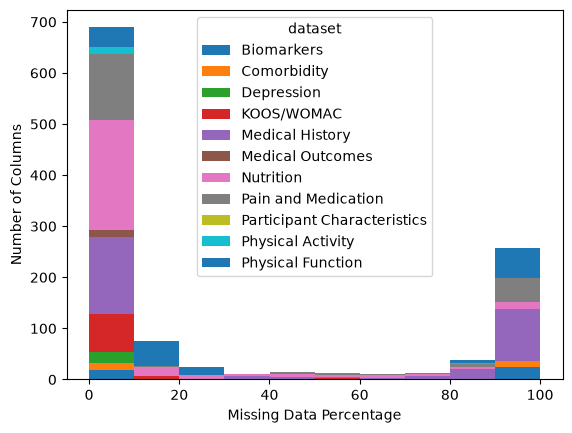

In [136]:
summary["total_missing"] = (summary["blank"] + summary["coded"])

summary["missing_pct"] = summary["total_missing"] / len(df) * 100


#summary.sort_values("missing_pct", ascending=False).head(50)
num_bins = 100
#n, bins, _ = plt.hist(summary["missing_pct"], num_bins, color='green', alpha=0.7)
summary.pivot(columns="dataset")["missing_pct"].plot(kind="hist", stacked=True, bins=10)
plt.xlabel("Missing Data Percentage")
plt.ylabel("Number of Columns")

In [7]:
dataset_missing = (
    summary.groupby("dataset").agg(
        columns=("dataset", "size"),
        total_missing=("total_missing", "sum"),
        avg_missing_pct=("missing_pct", "mean"),
    )
    .sort_values("avg_missing_pct", ascending=False)
)
dataset_missing

,columns,total_missing,avg_missing_pct
dataset,,,
Biomarkers,42,114863,57.023214
Comorbidity,28,62920,46.854522
Physical Function,170,359704,44.118138
Medical History,296,618999,43.603270
Pain and Medication,196,279508,29.734387
Physical Activity,18,14983,17.355898
Nutrition,279,192541,14.389306
Participant Characteristics,1,162,3.377815
KOOS/WOMAC,83,13247,3.327823


In [8]:
n = (summary["missing_pct"] > 80).sum()
print(f"{n} columns have more than 80% missing values")

296 columns have more than 80% missing values


In [9]:
#summary[summary["missing_pct"] > 80]

In [10]:
def clean_column(series, col_type):
    s = series.replace(".: Missing Form/Incomplete Workbook", np.nan)
    if col_type == "Continuous":
        return pd.to_numeric(s, errors="coerce")
    extracted = s.astype(str).str.extract(r"^\s*(-?\d+)\s*:")[0]
    numeric = pd.to_numeric(extracted, errors="coerce")
    fallback = pd.to_numeric(s, errors="coerce")
    
    return numeric.fillna(fallback)

type_map = df2.set_index("AllClinical00")["Type"].to_dict()

df_clean = df.copy()

for col, t in type_map.items():
    if col in df_clean.columns:
        df_clean[col] = clean_column(df_clean[col], t)

C:\Users\Ieva\AppData\Local\Temp\ipykernel_26608\1546172006.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = series.replace(".: Missing Form/Incomplete Workbook", np.nan)
C:\Users\Ieva\AppData\Local\Temp\ipykernel_26608\1546172006.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = series.replace(".: Missing Form/Incomplete Workbook", np.nan)
C:\Users\Ieva\AppData\Local\Temp\ipykernel_26608\1546172006.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain 

In [11]:
df_clean.head()

,ID,VERSION,V00BLDCOLL,V00BLDHRS1,V00BLDHRS2,V00BLDRAW1,V00BLDRAW2,V00BLSURD1,V00BLSURD2,V00CITRATE,...,V00PASE4,V00PASE4HR,V00PASE5,V00PASE5HR,V00PASE6,V00PASE6HR,V00WEEKWK,V00WKHR7CV,V00WORK7,V00WORKAMT
0,9000099.0,NaN,1,35400.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,3.0,1.0,2.0,1.0,52.0,50.0,1.0,1.0
1,9000296.0,NaN,1,30780.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,0.0,NaN,52.0,50.0,1.0,2.0
2,9000622.0,NaN,1,33900.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN
3,9000798.0,NaN,1,26400.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,0.0,NaN,52.0,40.0,1.0,3.0
4,9001104.0,NaN,1,35100.0,NaN,1,NaN,NaN,NaN,1,...,0,NaN,0.0,NaN,3.0,1.0,NaN,0.0,0.0,NaN


<Axes: >

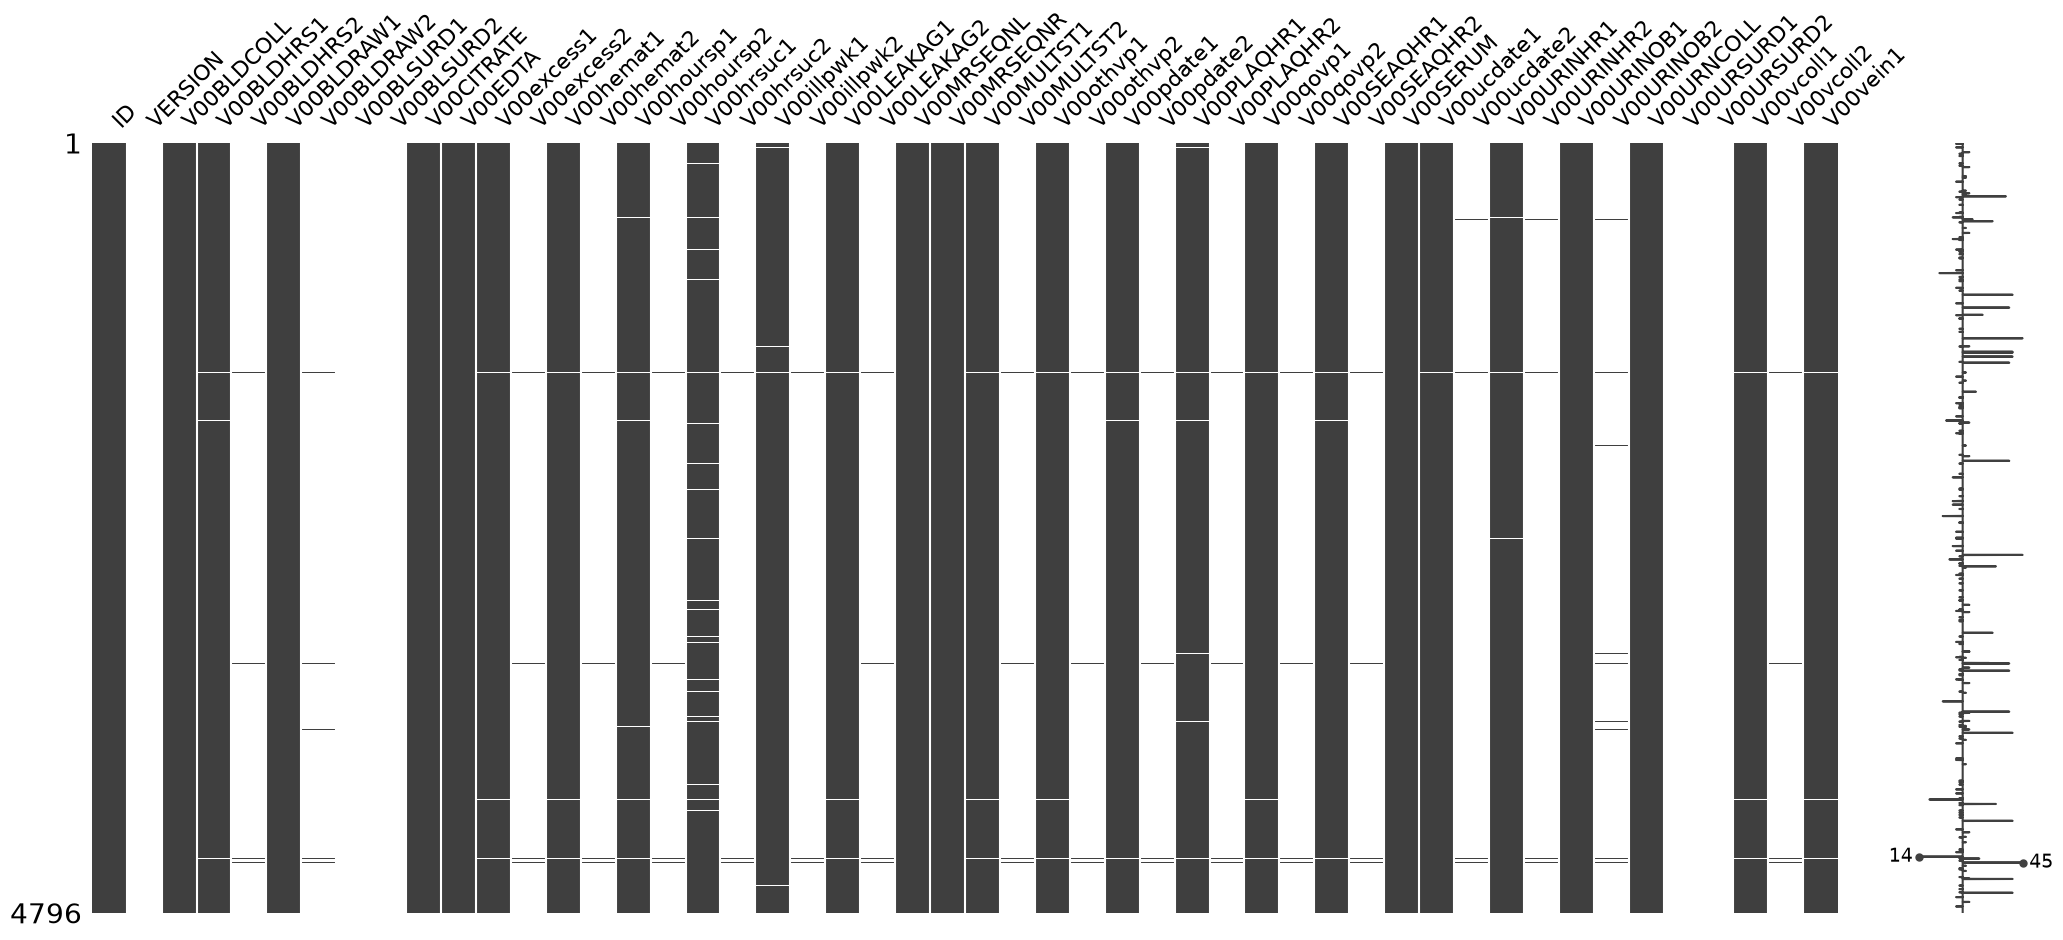

In [12]:
msno.matrix(df_clean.iloc[:, 0:50])


<Axes: >

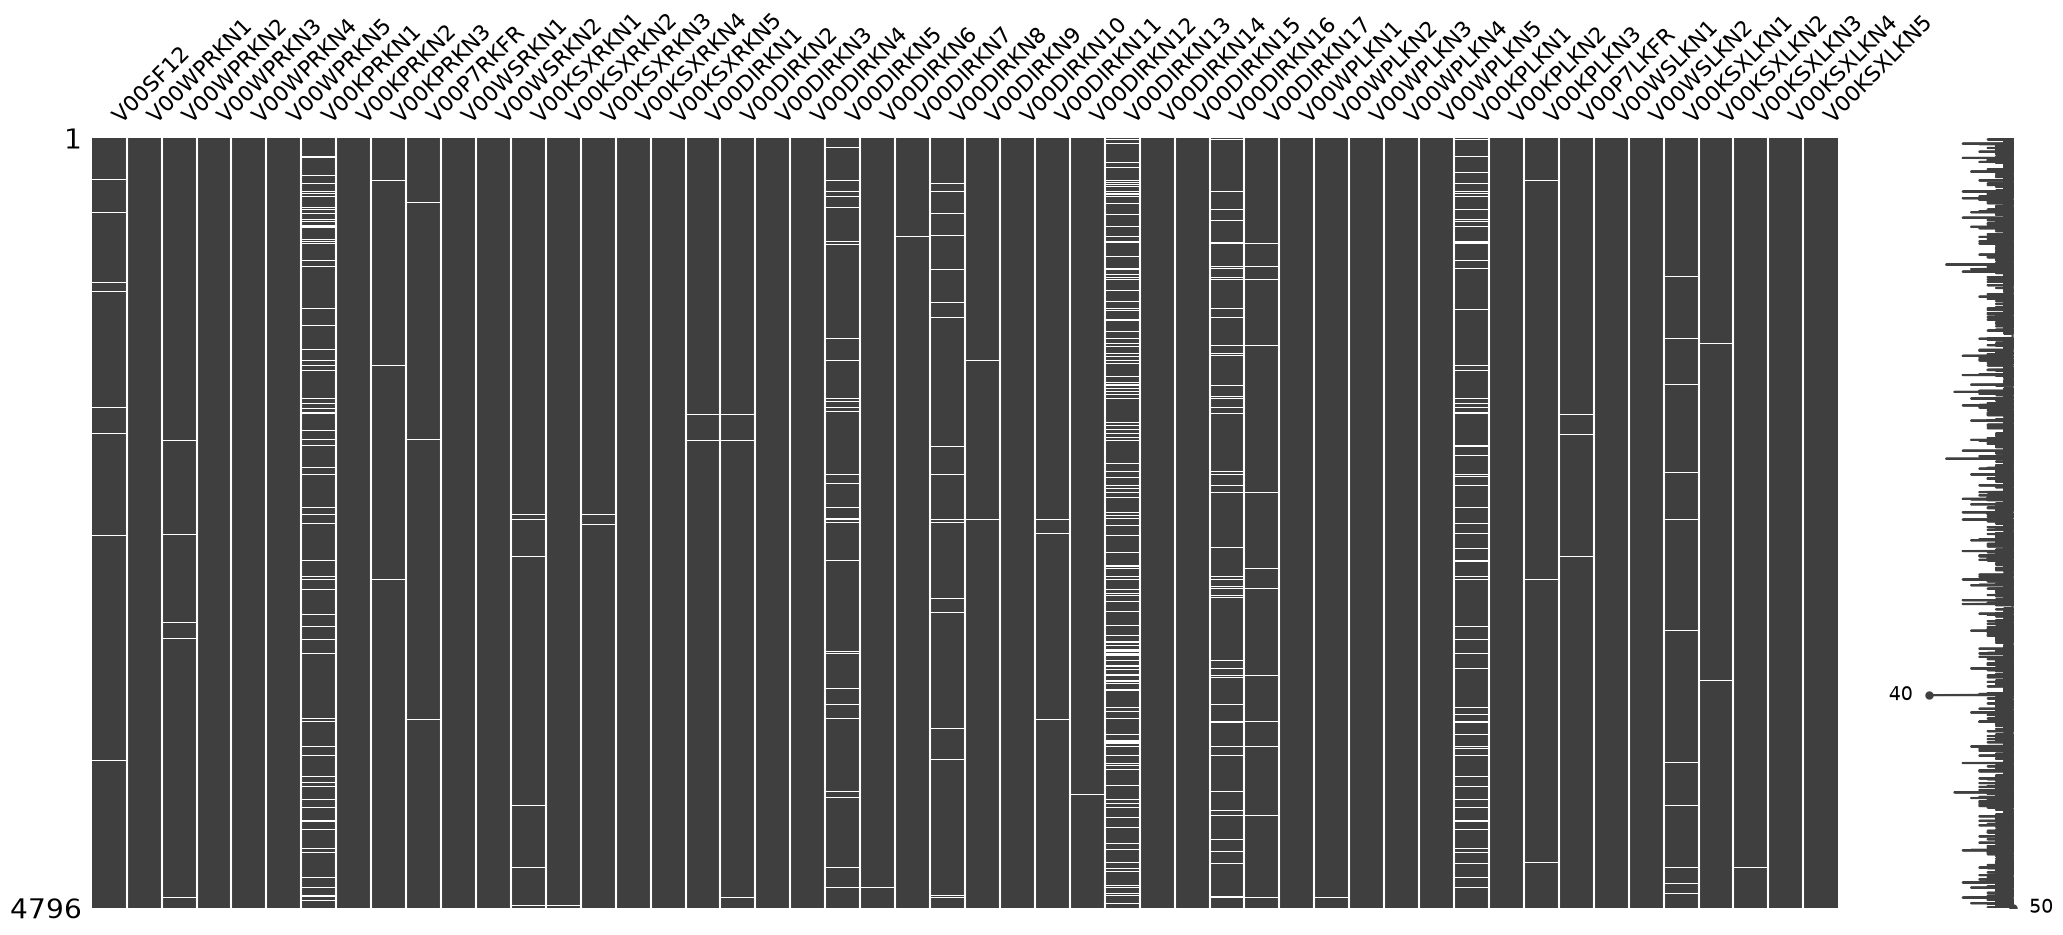

In [13]:
df_clean_drop = df_clean.dropna(axis=1, thresh=3837)
msno.matrix(df_clean_drop.iloc[:, 50:100])

In [14]:
target_l = df_clean["P01OAGRDL"]
target_r = df_clean["P01OAGRDR"]


In [168]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

miss_matrix = df_clean.isna().astype(int)

miss_matrix = miss_matrix.loc[:, (miss_matrix.sum() > 0) & (miss_matrix.sum() < len(miss_matrix)*0.8)]

miss_corr = miss_matrix.corr()

dist = pdist(miss_corr.fillna(0), metric="euclidean")
Z = linkage(dist, method="average")
clusters = fcluster(Z, t=11, criterion="maxclust")

cluster_map = pd.Series(clusters, index=miss_corr.columns, name="missing_cluster")
cluster_map.value_counts().sort_index()


missing_cluster
1     181
2      47
3      33
4      25
5      63
6      69
7      25
8      38
9       9
10      7
11    342
Name: count, dtype: int64

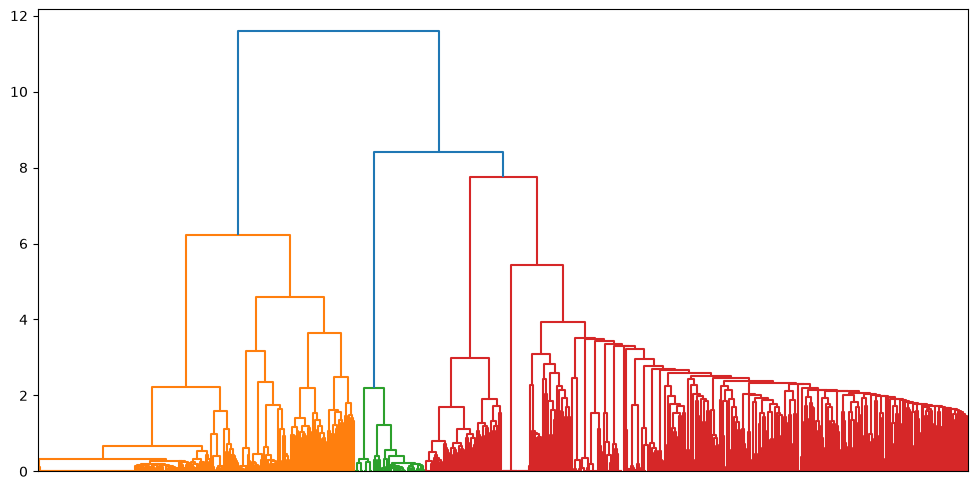

In [169]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12,6))
dendrogram(Z, labels=None, no_labels=True)
#plt.axhline(y=3.5, color="r", linestyle="--")
plt.show()

<Figure size 3000x2000 with 0 Axes>

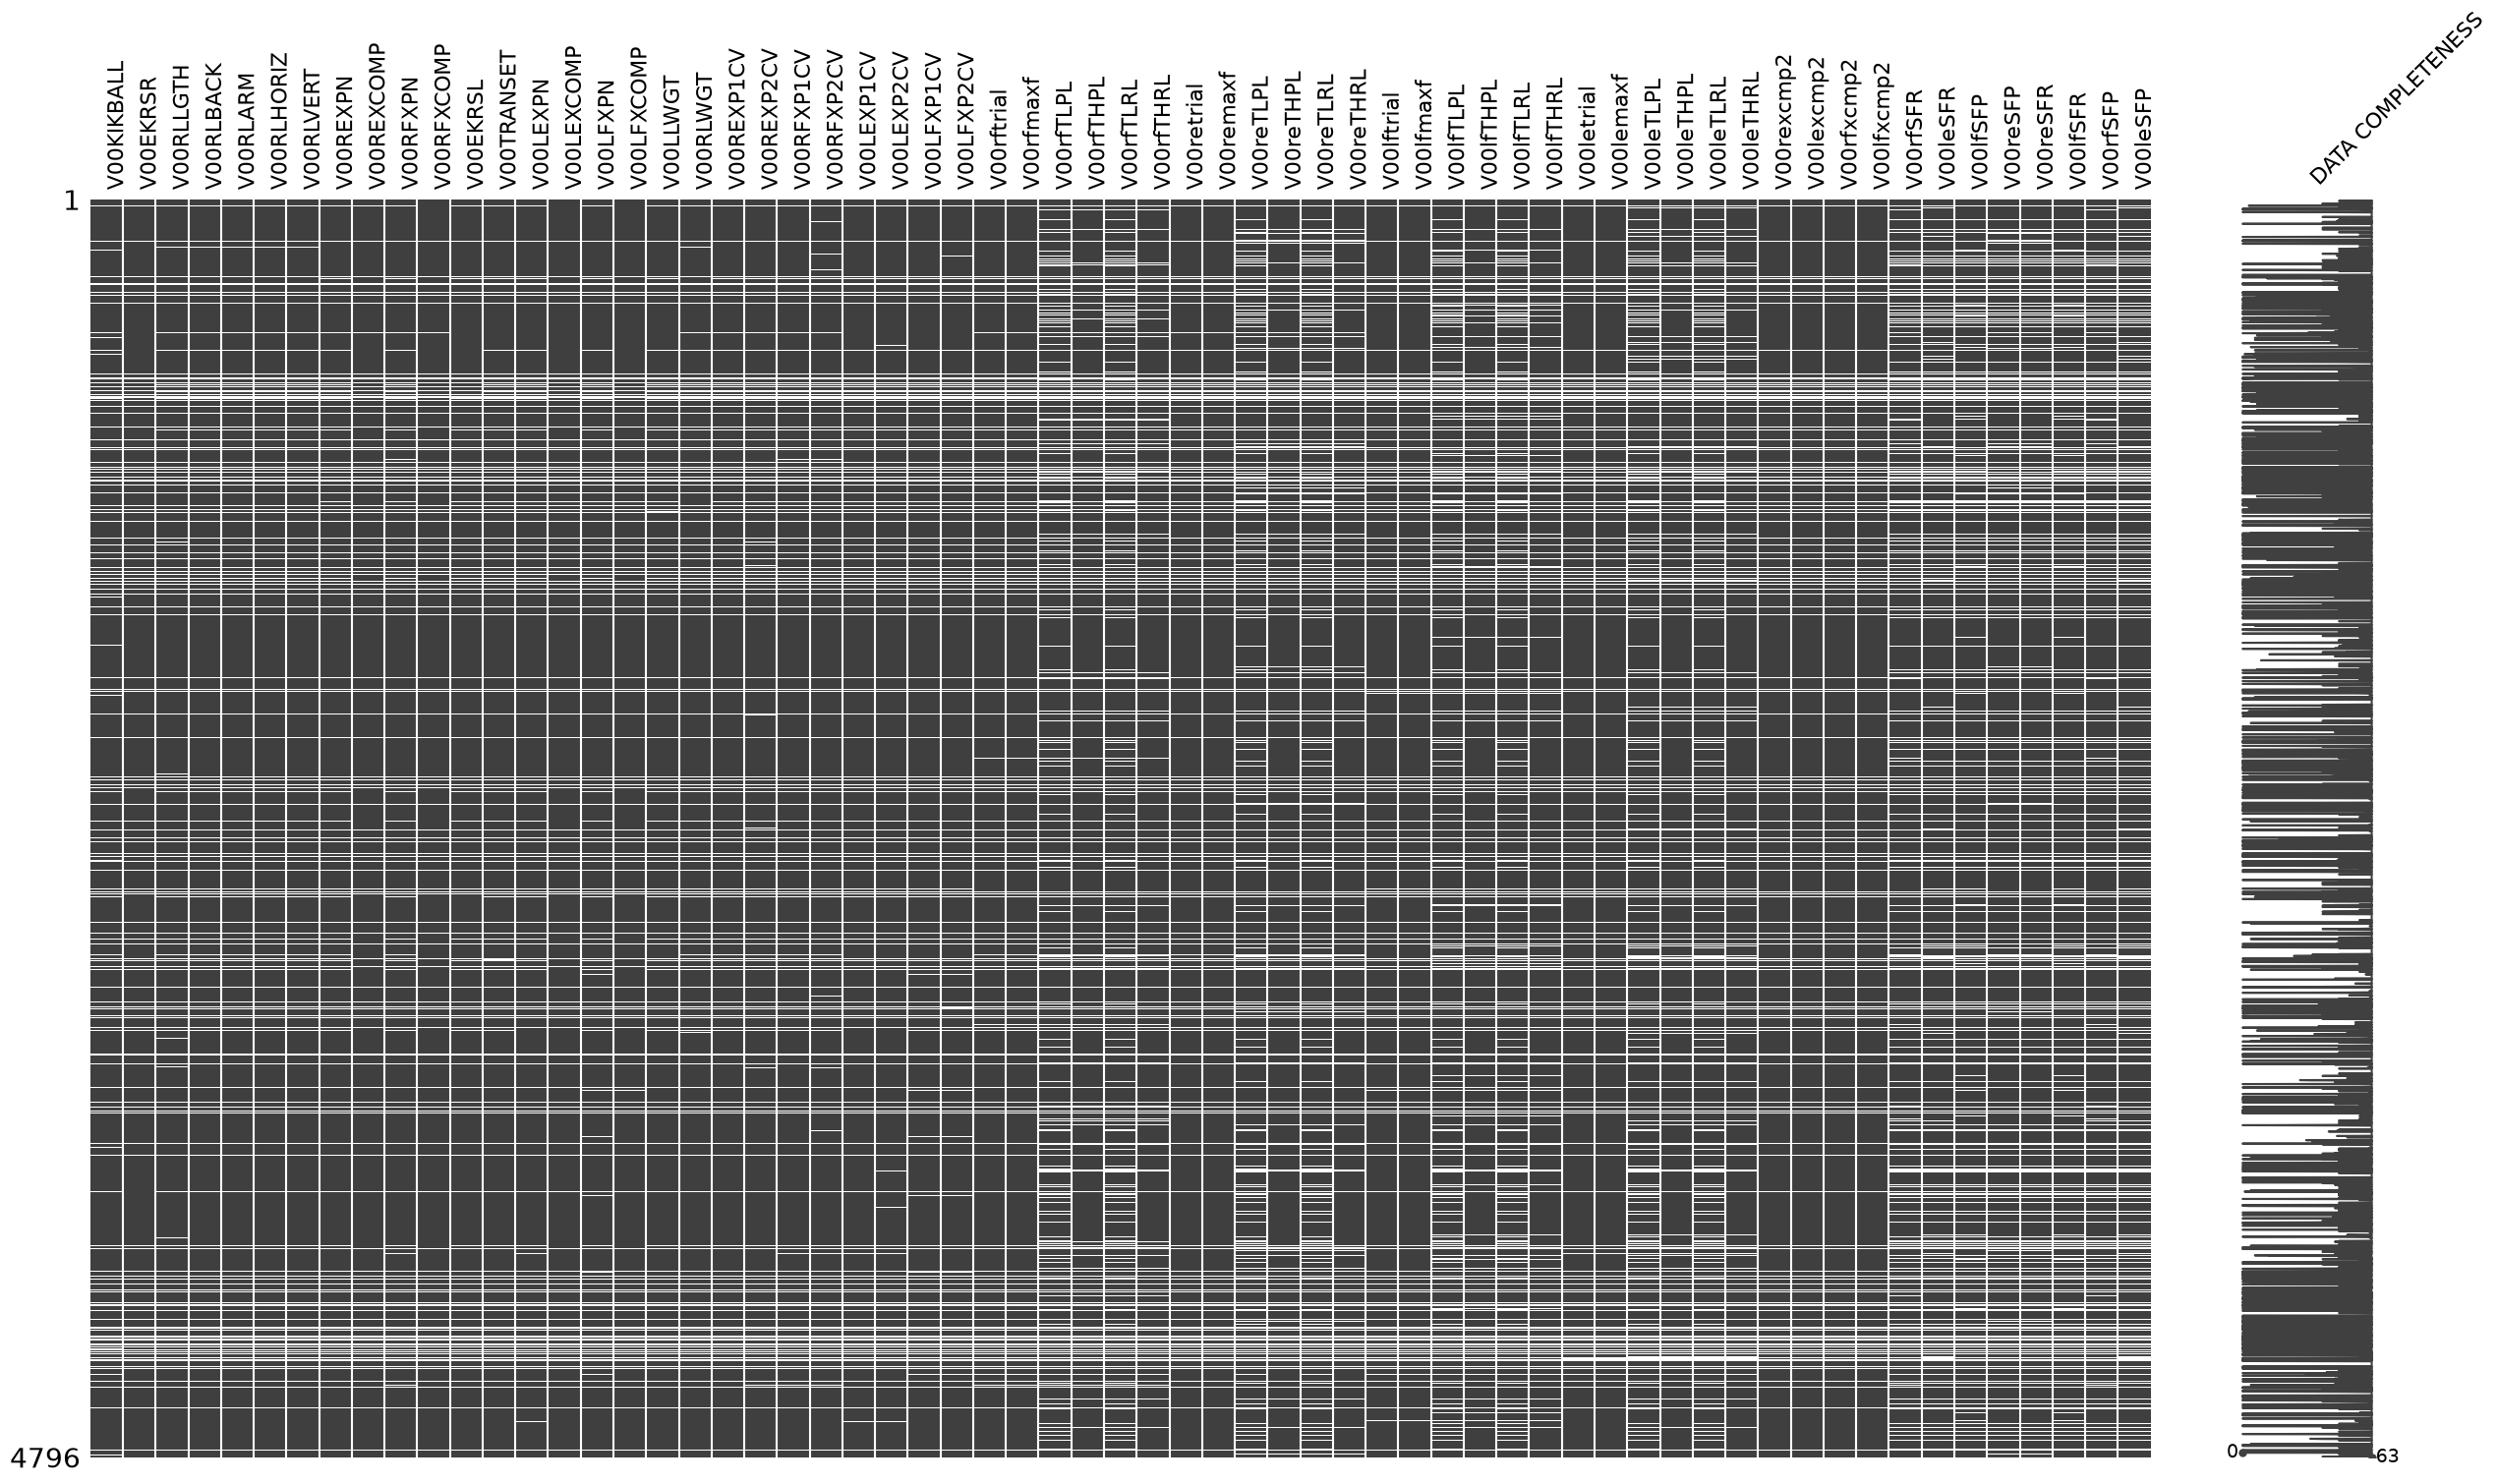

['V00KIKBALL', 'V00EKRSR', 'V00RLLGTH', 'V00RLBACK', 'V00RLARM', 'V00RLHORIZ', 'V00RLVERT', 'V00REXPN', 'V00REXCOMP', 'V00RFXPN', 'V00RFXCOMP', 'V00EKRSL', 'V00TRANSET', 'V00LEXPN', 'V00LEXCOMP', 'V00LFXPN', 'V00LFXCOMP', 'V00LLWGT', 'V00RLWGT', 'V00REXP1CV', 'V00REXP2CV', 'V00RFXP1CV', 'V00RFXP2CV', 'V00LEXP1CV', 'V00LEXP2CV', 'V00LFXP1CV', 'V00LFXP2CV', 'V00rftrial', 'V00rfmaxf', 'V00rfTLPL', 'V00rfTHPL', 'V00rfTLRL', 'V00rfTHRL', 'V00retrial', 'V00remaxf', 'V00reTLPL', 'V00reTHPL', 'V00reTLRL', 'V00reTHRL', 'V00lftrial', 'V00lfmaxf', 'V00lfTLPL', 'V00lfTHPL', 'V00lfTLRL', 'V00lfTHRL', 'V00letrial', 'V00lemaxf', 'V00leTLPL', 'V00leTHPL', 'V00leTLRL', 'V00leTHRL', 'V00rexcmp2', 'V00lexcmp2', 'V00rfxcmp2', 'V00lfxcmp2', 'V00rfSFR', 'V00leSFR', 'V00lfSFP', 'V00reSFP', 'V00reSFR', 'V00lfSFR', 'V00rfSFP', 'V00leSFP']


In [172]:
cols_in_cluster = cluster_map[cluster_map==5].index.to_list()


fig = plt.figure(figsize=(30, 20))
ax = msno.matrix(df_clean[cols_in_cluster], labels=True, figsize=(30,20))#.sample(min(len(df_clean), 800)))
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.subplots_adjust(top=0.75)
plt.show()


print(cols_in_cluster)

In [170]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

source_dataset = df2.set_index("AllClinical00")["Dataset"]

compare_df = pd.DataFrame({
    "missing_cluster" : cluster_map,
    "dataset" : source_dataset.reindex(cluster_map.index)
})

ari = adjusted_rand_score(compare_df["missing_cluster"], compare_df["dataset"])
print(f"Adjusted Rand Index: {ari:.3f}")
nmi = normalized_mutual_info_score(compare_df["missing_cluster"], compare_df["dataset"])
print(f"Normalized Mutual Info: {nmi:.3f}")

Adjusted Rand Index: 0.329
Normalized Mutual Info: 0.551


In [171]:
import seaborn as sns

ct = pd.crosstab(compare_df["missing_cluster"], compare_df["dataset"])
ct

dataset,Biomarkers,Comorbidity,Depression,KOOS/WOMAC,Medical History,Medical Outcomes,Nutrition,Pain and Medication,Participant Characteristics,Physical Activity,Physical Function
missing_cluster,,,,,,,,,,,
1,0,0,0,0,0,0,181,0,0,0,0
2,0,0,0,0,16,0,0,12,0,0,19
3,0,0,0,0,0,0,33,0,0,0,0
4,0,0,0,0,0,0,25,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,63
6,0,13,21,0,21,14,0,0,0,0,0
7,0,0,0,0,0,0,0,25,0,0,0
8,0,2,0,0,15,0,20,0,0,0,1
9,0,0,0,0,9,0,0,0,0,0,0


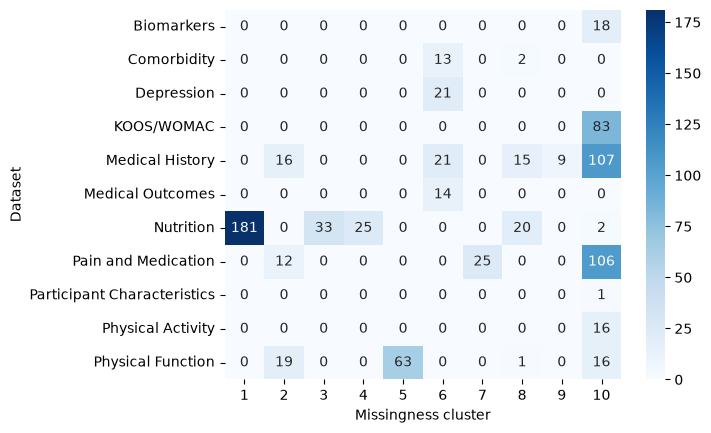

In [159]:
sns.heatmap(ct.transpose(), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Missingness cluster")
plt.ylabel("Dataset")
plt.show()

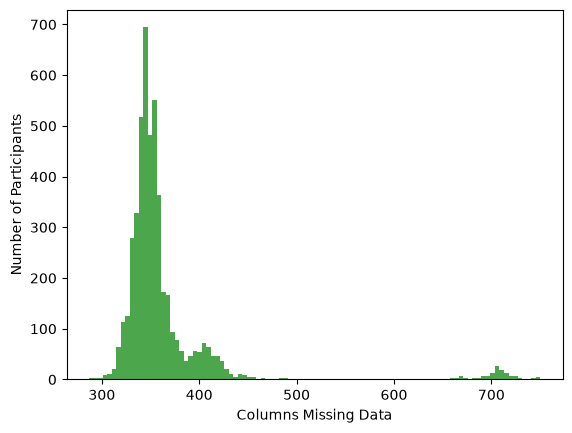

0       369
1       350
2       343
3       324
4       338
       ... 
4791    348
4792    368
4793    377
4794    357
4795    344
Length: 4796, dtype: int64


In [157]:
id_missing = df_clean.isnull().sum(axis=1)


n, bins, _ = plt.hist(id_missing, num_bins, color='green', alpha=0.7)
plt.ylabel("Number of Participants")
plt.xlabel("Columns Missing Data")
plt.show()

print(id_missing)

In [155]:
df_clean.shape

(4796, 1187)

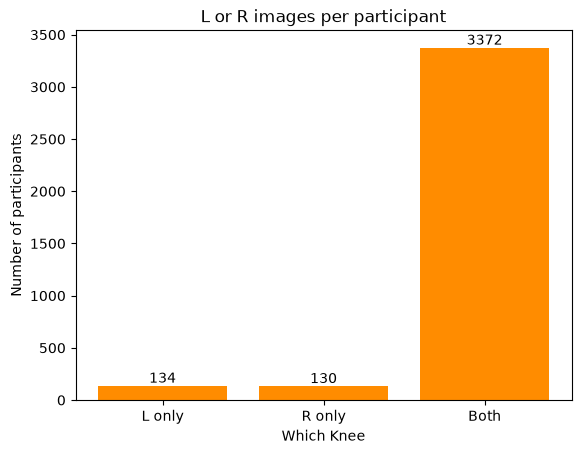

In [166]:
from collections import defaultdict

root = Path("../data/raw/knee_images")

images = defaultdict(set)

for file in root.rglob("*"):
    if file.is_file():
        name = file.stem

        if len(name) == 8 and name[:7].isdigit() and name[7] in {"L", "R"}:
            image_id = name[:7]
            side = name[7]
            images[image_id].add(side)

l_only = sum(sides =={"L"} for sides in images.values())
r_only = sum(sides =={"R"} for sides in images.values())
both = sum(sides == {"L", "R"} for sides in images.values())

categories = ["L only", "R only", "Both"]
counts = [l_only, r_only, both]

plt.bar(categories, counts, color="darkorange")


for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha="center", va="bottom")

plt.xlabel("Which Knee")
plt.ylabel("Number of participants")
plt.title("L or R images per participant")

plt.show()

defaultdict(<class 'set'>, {'9003175': {'R'}, '9003316': {'L'}, '9003430': {'L', 'R'}, '9003658': {'L', 'R'}, '9003815': {'L', 'R'}, '9004184': {'L', 'R'}, '9004315': {'L', 'R'}, '9004669': {'L', 'R'}, '9005075': {'L', 'R'}, '9005321': {'L', 'R'}, '9005656': {'L', 'R'}, '9006407': {'L'}, '9007904': {'L', 'R'}, '9008820': {'L', 'R'}, '9009623': {'L', 'R'}, '9009927': {'L'}, '9009957': {'L'}, '9010308': {'L', 'R'}, '9010370': {'L', 'R'}, '9010952': {'L', 'R'}, '9011115': {'L', 'R'}, '9011641': {'L', 'R'}, '9011949': {'L', 'R'}, '9013634': {'L', 'R'}, '9013941': {'L', 'R'}, '9014883': {'L', 'R'}, '9015363': {'L', 'R'}, '9015718': {'R'}, '9015798': {'L', 'R'}, '9016121': {'L', 'R'}, '9016179': {'L', 'R'}, '9016886': {'L', 'R'}, '9017419': {'L', 'R'}, '9017909': {'L', 'R'}, '9018489': {'L', 'R'}, '9019287': {'L', 'R'}, '9019406': {'L', 'R'}, '9020856': {'L', 'R'}, '9020999': {'L', 'R'}, '9021195': {'L', 'R'}, '9021428': {'L', 'R'}, '9022197': {'L', 'R'}, '9022289': {'L', 'R'}, '9022408': {'